## Tutorial on human breast cancer dataset.

 This demo demonstrates how to use **STAID** to deconvolve spatial transcriptomics (ST) data with the help of single-cell RNA-seq (scRNA-seq) reference data.
We will use a **breast cancer dataset** as an example.


### 1. Import packages

In [1]:
import os
import scanpy as sc
from staid.utils import seed_everything
from staid import run_deconvolution

### 2. Load data

The human breast cancer Visium datasets are available at https://doi.org/10.5281/zenodo.4739739 and match human breast cancer scRNA-seq reference datasets are available through the Gene Expression Omnibus under accession number GSE176078. For convenience, we also provide a sorted version on Google Drive: [Download from Google Drive](https://drive.google.com/drive/folders/1-GhHslCBIYvNFb1Zs3DmLKVg9JZx1QSP?usp=sharing).

In [2]:
# Set dataset paths
sample = "CID4535"
spa_data_path = "/opt/data/private/jxliu/project/staid/data/Breast_cancer/merged_datasets"
sc_data_path = "/opt/data/private/jxliu/project/staid/data/scRNA-seq/Breast_cancer"

# Load AnnData objects
sp_adata = sc.read_h5ad(os.path.join(spa_data_path,
                                     f"{sample}_visium_breast_cancer.h5ad"))
sc_adata = sc.read_h5ad(os.path.join(sc_data_path,
                                     f"{sample}_scRNA_seq_with_annotations.h5ad"))

### 3. Preprocessing

Just filter genes with low expression ratios and keep the raw gene expression counts.

In [3]:
sp_adata.var_names_make_unique()
sc_adata.var_names_make_unique()

sc.pp.filter_genes(sp_adata, min_cells=10)
sc.pp.filter_genes(sc_adata, min_cells=10)

### 4. Run deconvolution

We now run the iterative deconvolution process.
For this demo, we set the number of iterations (num_iter) to 5 for faster execution.

In [4]:
# set seed
seed_everything(2025)
# set annotation key in sc_adata.obs.keys()
anno_key = "celltype_major"

cell_type_df = run_deconvolution(
    sp_adata=sp_adata,
    sc_adata=sc_adata,
    anno_key=anno_key,
    device="cuda:0",          # use GPU
    lr=0.0005,
    num_pseudo=5000,
    num_iter=5,
    batch_size=128,
    min_cells=1,
    max_cells=10,
    batch_correction="scanorama",   # platform correction
    hidden_dims=[512, 256, 256],
    library_size=1e4,
    dropout=0.1,
    c=0.1,
    weight=1e-5
)

The number of marker genes: 3872
*************** Iteration: 	1 ***************


Epoch:  75%|███████▌  | 150/200 [00:45<00:15,  3.32it/s, loss=0.00138]


*************** Iteration:	2 ***************


Epoch:  13%|█▎        | 26/200 [00:05<00:38,  4.52it/s, loss=0.00132]


*************** Iteration:	3 ***************


Epoch:  10%|█         | 20/200 [00:04<00:38,  4.63it/s, loss=0.000965]


*************** Iteration:	4 ***************


Epoch:  18%|█▊        | 35/200 [00:07<00:34,  4.73it/s, loss=0.000648]


*************** Iteration:	5 ***************


Epoch:  10%|█         | 21/200 [00:04<00:35,  5.06it/s, loss=0.000888]


The cell type composition information can be obtained in ```cell_type_df```:

In [5]:
cell_type_df.iloc[:5, :5]

,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid
AACATTGGTCAGCCGT-1,0.933518,0.006616,0.000000,0.000000,0.000000
CATCGAATGGATCTCT-1,0.000000,0.000000,0.192064,0.000000,0.000000
GCGTCCAGCTCGTGGC-1,0.000000,0.000000,0.719807,0.000000,0.115706
CCAAAGTCCCGCTAAC-1,0.000000,0.068452,0.794619,0.005912,0.121707
GTTACGGCCCGACTGC-1,0.000000,0.000000,0.555312,0.000000,0.235157


### 5. Visualization

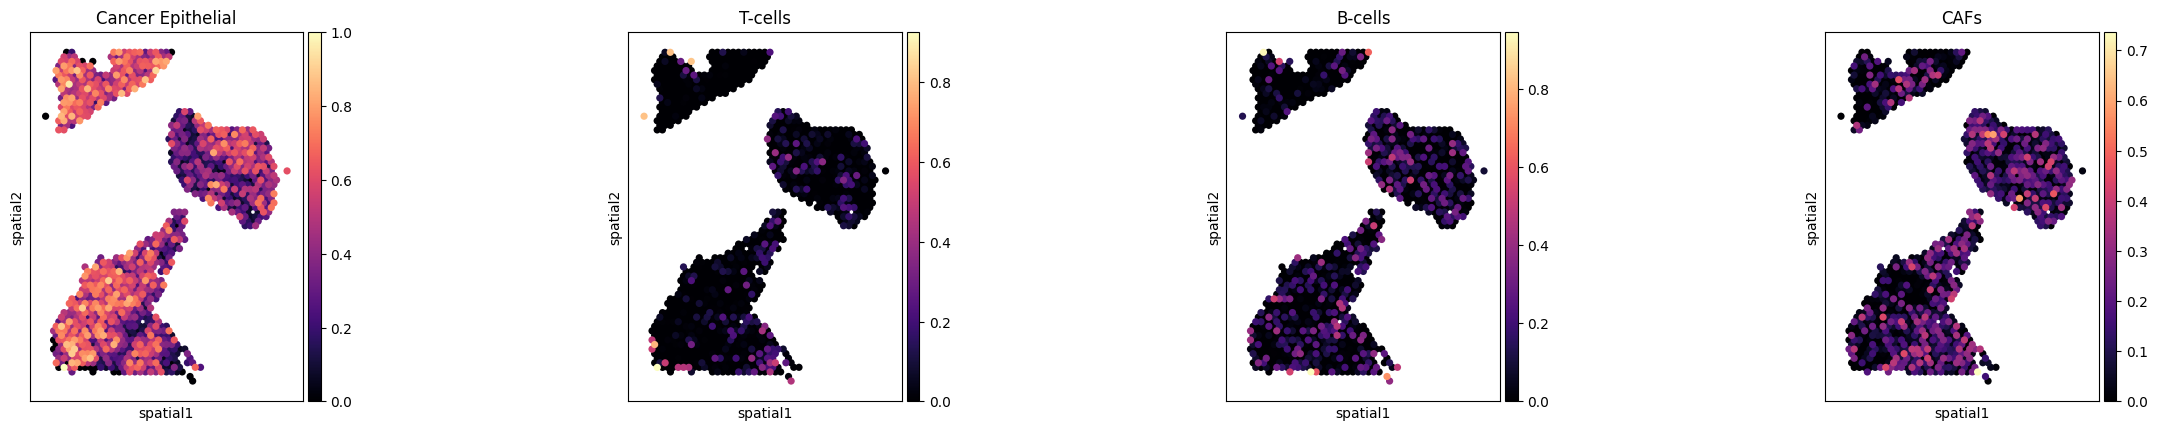

In [6]:
cell_type_list = ['Cancer Epithelial', 'T-cells', 'B-cells', 'CAFs']
sp_adata.obs[cell_type_list] = cell_type_df[cell_type_list].copy()
sc.pl.spatial(sp_adata, color=cell_type_list, cmap='magma', spot_size=150, img_key=None, ncols=4)